In [15]:
# Import all functions from the required modules
from cordo_sherpa_module import *
from cordo_chimere_module import *
from expo_functions_module import *
from association_module import *
from cessation_lag_module import *
print("Successfully loaded all modules")

Successfully loaded all modules


In [16]:
# Paths to the files
path_fichier_shp = "data/2-output-data/donnees_shp"
title_shp = "donnees_insee_iris"
path_fichier_pourcents = "data/2-output-data"
title_pourcents = "pourcents"

# Load the concentration points
conc_points = coordo_sherpa(sc="s1", pol="ug_NO2", year=2019)

# Load the exported data
donnees_exportees = gpd.read_file(os.path.join(path_fichier_shp, f"{title_shp}.shp"))

# Transform the CRS of the exported data to match the concentration points
donnees_exportees_transformed = donnees_exportees.to_crs(epsg=conc_points.crs.to_epsg())

# Check if CRSs are the same
if conc_points.crs == donnees_exportees_transformed.crs:
    print("CRS for conc_points_transformed and donnees_exportees_transformed are the same.")
else:
    print("CRS for conc_points_transformed and donnees_exportees_transformed are different.")

Concentrations in 2019 and 2019 are calculated for the pollutant 'ug_no2' (s1).
CRS for conc_points_transformed and donnees_exportees_transformed are the same.


In [17]:
import os
# Define paths for shapefiles
path_fichier_shp = "data/2-output-data/donnees_shp"
path_fichier_shp_1 = "data/2-output-data/donnees_shp_1"
path_fichier_shp_2 = "data/2-output-data/donnees_shp_2"
path_fichier_shp_3 = "data/2-output-data/donnees_shp_3"
path_fichier_pourcents = "data/2-output-data"

# Titles for INSEE Data
title_shp = "donnees_insee_iris"
title_shp_1 = "donnees_insee_iris_toutage_1"
title_shp_2 = "donnees_insee_iris_toutage_2"
title_shp_3 = "donnees_insee_iris_toutage_3"
title_pourcents = "pourcents"

# Read shapefiles into GeoDataFrames
donnees_shp_1 = gpd.read_file(os.path.join(path_fichier_shp_1, f"{title_shp_1}.shp"))
donnees_shp_2 = gpd.read_file(os.path.join(path_fichier_shp_2, f"{title_shp_2}.shp"))
donnees_shp_3 = gpd.read_file(os.path.join(path_fichier_shp_3, f"{title_shp_3}.shp"))

# Combine the three GeoDataFrames
donnees_merged = gpd.GeoDataFrame(pd.concat([donnees_shp_1, donnees_shp_2, donnees_shp_3], ignore_index=True))
print(donnees_merged.head())

grille_combinee = gpd.read_file(os.path.join(path_fichier_pourcents, f"{title_pourcents}.shp"))
grille_combinee = grille_combinee.to_crs(conc_points.crs)

     iriscod irisname comcod comname depcod depname  regcod           regname  \
0  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
1  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
2  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
3  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
4  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   

   age    pop2019    pop2030    pop2050  mort2019  mort2030  mort2050  \
0    0  31.979362  30.560224  28.974134  0.114652  0.101665  0.085457   
1    1  32.735555  30.384526  29.200275  0.018369  0.016510  0.014105   
2    2  33.511730  30.265005  29.417218  0.008333  0.007299  0.006310   
3    3  34.431724  30.206960  29.615683  0.005018  0.004605  0.004083   
4    4  35.587474  30.214303  29.787011  0.003853  0.003519  0.003135   

                                            geometry  
0  POLYGON ((497887

In [18]:
#Function to compute the exposure change from the anchor years and pre-defined functions
def build_exposure_cache_for_anchors(scenario, pollutant, donnees_exportees_transformed, grille_combinee):
    expo_cache = {}
    for y in ANCHOR_YEARS:
        logging.info(f"[ANCHOR] Computing exposure: Scenario={scenario}, Pollutant={pollutant}, Year={y}")

        conc_points = coordo_chimere(pollutant, year=y, SC=scenario.upper())
        conc_points = conc_points.to_crs(donnees_exportees_transformed.crs)

        conc_chimere = coordo_ineris_chimere(pollutant, year="2019")
        conc_chimere = conc_chimere.to_crs(donnees_exportees_transformed.crs)

        conc_corrige = correction_chimere(conc_points, conc_chimere)
        expo_cache[int(y)] = expo(donnees_exportees_transformed, conc_corrige, grille_combinee)

    return expo_cache

In [19]:
#helper function for non-linear exposure change and lagged RR adjustment
#codes to calculate delay weights for different lag structures (linear, cosine, exponential) and to compute cumulative effect fractions based on these weights
def calculate_delay_weights_linear(lag_years=20):
    """
    Linear delay weights over lag periods (uniform realization over lag_years).
    """
    lag_years = int(lag_years)
    if lag_years <= 0:
        raise ValueError("lag_years must be > 0.")
    return np.ones(lag_years, dtype=float) / float(lag_years)

def caculate_delay_weights_cosine(lag_years=20):
    """
    Non-linear delay weights over lag periods using a *cosine* realization curve.
    We return per-year weights as differences of the cosine CDF so weights sum to 1.
    """
    lag_years = int(lag_years)
    if lag_years <= 0:
        raise ValueError("lag_years must be > 0.")
    edges = np.arange(lag_years + 1, dtype=float)
    cdf = 0.5 * (1.0 - np.cos(np.pi * edges / float(lag_years)))
    weights = np.diff(cdf)
    s = weights.sum()
    if not np.isfinite(s) or s <= 0:
        raise ValueError("Invalid cosine weights; sum must be positive and finite.")
    return weights / s

def calculate_delay_weights_exponential(lag_years=20, decay_rate=0.1):
    """
    Non-linear delay weights over lag periods using a *sigmoidal (logistic)* realization curve.
    - `decay_rate` controls steepness (higher => faster realization around the midpoint).
    We return per-year weights as differences of the logistic CDF so weights sum to 1.
    """
    lag_years = int(lag_years)
    if lag_years <= 0:
        raise ValueError("lag_years must be > 0.")
    decay_rate = float(decay_rate)
    if decay_rate < 0:
        raise ValueError("decay_rate must be >= 0.")
    # Map decay_rate to logistic steepness. Keep stable defaults if decay_rate==0.
    k = 8.0 * decay_rate if decay_rate > 0 else 1.0
    # Midpoint in "year index" space; symmetric S-curve over the lag window.
    m = (lag_years - 1) / 2.0
    # Logistic CDF sampled at bin edges (years as [0,1),[1,2),...,[L-1,L)).
    edges = np.arange(lag_years + 1, dtype=float)
    # Numerically stable logistic: 1 / (1 + exp(-z))
    z = k * (edges - m)
    cdf = 1.0 / (1.0 + np.exp(-z))
    weights = np.diff(cdf)
    s = weights.sum()
    if not np.isfinite(s) or s <= 0:
        raise ValueError("Invalid sigmoidal weights; sum must be positive and finite.")
    return weights / s

#Adjust for back leap in exposure trajectories (smooth rebound increases) to avoid unrealistic jumps in RR when applying lag structures
def adjust_for_back_leap(exposure_values):
    exposure_values = np.asarray(exposure_values, dtype=float)
    adjusted_values = np.copy(exposure_values)
    for i in range(1, len(exposure_values)):
        if exposure_values[i] > adjusted_values[i - 1]:
            adjusted_values[i] = (exposure_values[i] + adjusted_values[i - 1]) / 2.0
    return adjusted_values

#Codes to generate cessation lag fractions for evaluation years based on the delay weights and to adjust relative risks with these cessation lag fractions
def cumulative_effect_fraction(eval_years, base_year, delay_weights):
    eval_years = np.asarray(eval_years, dtype=int)
    base_year = int(base_year)
    delay_weights = np.asarray(delay_weights, dtype=float)
    L = int(delay_weights.size)
    out = np.zeros_like(eval_years, dtype=float)
    if L == 0:
        return out
    cumw = np.cumsum(delay_weights)
    diffs = eval_years - base_year
    valid = diffs >= 0
    if np.any(valid):
        idx = diffs[valid]
        idx = np.minimum(idx, L - 1)
        out[valid] = cumw[idx]
    return out

def generate_cessation_lag_fractions(base_year, eval_years, lag_years=20, decay_rate=0.1):
    delay_weights_linear = calculate_delay_weights_linear(lag_years=lag_years)
    delay_weights_exponential = calculate_delay_weights_exponential(
        lag_years=lag_years, decay_rate=decay_rate)
    delay_weights_cosine = caculate_delay_weights_cosine(lag_years=lag_years)
    frac_linear = cumulative_effect_fraction(eval_years, base_year, delay_weights_linear)
    frac_exponential = cumulative_effect_fraction(eval_years, base_year, delay_weights_exponential)
    frac_cosine = cumulative_effect_fraction(eval_years, base_year, delay_weights_cosine)

    return delay_weights_linear, delay_weights_exponential, delay_weights_cosine, frac_linear, frac_exponential, frac_cosine

def adjusted_rr_with_cessation_lag(rr_full_effect, effect_fraction):
    rr_full_effect = np.asarray(rr_full_effect, dtype=float)
    effect_fraction = np.asarray(effect_fraction, dtype=float)
    return 1.0 + (rr_full_effect - 1.0) * effect_fraction

def _pick_exposure_series(donnees_expo, pollutant):
    if pollutant in donnees_expo.columns:
        s = pd.to_numeric(donnees_expo[pollutant], errors="coerce")
        if s.notna().any():
            return s
    numeric_cols = donnees_expo.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 0:
        s = pd.to_numeric(donnees_expo.select_dtypes(exclude=[object]).iloc[:, 0], errors="coerce")
        return s
    s = pd.to_numeric(donnees_expo[numeric_cols[0]], errors="coerce")
    return s

def exposure_mean_from_cache(expo_cache, pollutant):
    means = {}
    for y, df in expo_cache.items():
        s = _pick_exposure_series(df, pollutant)
        means[int(y)] = float(np.nanmean(s.to_numpy(dtype=float)))
    return means

def interpolate_exposure_means_linear(eval_years, anchor_means):
    anchor_years = _validate_anchor_years(anchor_means.keys())
    x = np.array(anchor_years, dtype=float)
    y = np.array([float(anchor_means[yr]) for yr in anchor_years], dtype=float)
    f = interp1d(x, y, kind="linear", fill_value="extrapolate")
    return np.asarray(f(np.asarray(eval_years, dtype=float)), dtype=float)

def _ease_in_out_exp(t, k=4.0):
    t = np.asarray(t, dtype=float)
    t = np.clip(t, 0.0, 1.0)
    t2 = np.clip(2.0 * t, 0.0, 2.0)
    left = 0.5 * np.power(t2, k)
    right = 1.0 - 0.5 * np.power(2.0 - t2, k)
    return np.where(t <= 0.5, left, right)

def interpolate_exposure_means_nonlinear(eval_years, anchor_means, k=1.0):
    anchor_years = _validate_anchor_years(anchor_means.keys())
    eval_years = np.asarray(eval_years, dtype=int)
    out = np.zeros_like(eval_years, dtype=float)
    for i, yr in enumerate(eval_years):
        if yr <= anchor_years[0]:
            out[i] = float(anchor_means[anchor_years[0]])
            continue
        if yr >= anchor_years[-1]:
            out[i] = float(anchor_means[anchor_years[-1]])
            continue
        lo = max(y for y in anchor_years if y <= yr)
        hi = min(y for y in anchor_years if y >= yr)
        if lo == hi:
            out[i] = float(anchor_means[lo])
            continue
        t = (float(yr) - float(lo)) / (float(hi) - float(lo))
        w = float(_ease_in_out_exp(t, k=k))
        out[i] = float(anchor_means[lo]) + w * (float(anchor_means[hi]) - float(anchor_means[lo]))
    return out

def interpolate_exposure_means_cosine(eval_years, anchor_means):
    anchor_years = _validate_anchor_years(anchor_means.keys())
    eval_years = np.asarray(eval_years, dtype=int)
    out = np.zeros_like(eval_years, dtype=float)
    for i, yr in enumerate(eval_years):
        if yr <= anchor_years[0]:
            out[i] = float(anchor_means[anchor_years[0]])
            continue
        if yr >= anchor_years[-1]:
            out[i] = float(anchor_means[anchor_years[-1]])
            continue
        lo = max(y for y in anchor_years if y <= yr)
        hi = min(y for y in anchor_years if y >= yr)
        if lo == hi:
            out[i] = float(anchor_means[lo])
            continue
        t = (float(yr) - float(lo)) / (float(hi) - float(lo))
        w = 0.5 * (1.0 - np.cos(np.pi * t))
        out[i] = float(anchor_means[lo]) + w * (float(anchor_means[hi]) - float(anchor_means[lo]))
    return out

def rr_from_exposure_change(exposure_year, exposure_base, rr_per_unit, unit_change=10.0):
    exposure_year = np.asarray(exposure_year, dtype=float)
    rr_per_unit = float(rr_per_unit)
    unit_change = float(unit_change)

    if unit_change <= 0:
        raise ValueError("unit_change must be > 0.")
    # If exposure_base is None: compute absolute RR relative to 0 exposure (RR reflects full exposure level)
    if exposure_base is None:
        return np.power(rr_per_unit, exposure_year / unit_change)

    exposure_base = float(exposure_base)
    delta = exposure_year - exposure_base
    return np.power(rr_per_unit, delta / unit_change)

In [20]:
# Calculation of effect fractions with both linear, cosine and sigmoidal decay
import os
import logging
import warnings
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Suppress warningsx
warnings.simplefilter(action="ignore", category=FutureWarning)

# Configure logging for the main script
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# Task summary:
# - Compute exposure changes (2019..2050) from anchor-year exposures (2019/2030/2050)
# - Convert exposure changes to yearly RR using mapped mortality RR (e.g., RR_MORTALITY_MAP)
# - Apply cessation-lag adjustment to RR (gradual realization of excess risk)
# - Store series needed to plot adjusted RR, exposure change, weights and AF later

# Define scenarios, pollutants, and years
scenarios = ["s1", "s2", "s3", "s4"]  # example scenarios; adjust as needed
pollutants = ["ug_NO2"]  # run one-by-one to avoid memory issues "ug_PM25_RH50"
years = list(range(2010, 2070))  # evaluation years
ANCHOR_YEARS = [2019, 2030, 2050]

def _validate_anchor_years(anchor_years):
    anchor_years = sorted(set(int(y) for y in anchor_years))
    if len(anchor_years) < 2:
        raise ValueError("Need at least two anchor years to interpolate.")
    return anchor_years


ANCHOR_YEARS = _validate_anchor_years(ANCHOR_YEARS)
# Align CRS of shapefiles to the CRS of donnees_exportees_transformed
target_crs = donnees_exportees_transformed.crs
donnees_exportees_transformed = donnees_exportees_transformed.to_crs(target_crs)
grille_combinee = grille_combinee.to_crs(target_crs)

# Baseline year for lag + exposure-change anchoring
BASELINE_YEAR = int(globals().get("LAG_BASE_YEAR", 2019))

# Cessation-lag structures: linear uniform and non-linear (sigmoidal) over 20 years
LAG_YEARS = 20
delay_w_linear, delay_w_exponential, delay_w_cosine, frac_linear, frac_exponential, frac_cosine = generate_cessation_lag_fractions(base_year=BASELINE_YEAR, eval_years=years, lag_years=LAG_YEARS, decay_rate=0.1)

# Use mapped RR for mortality (assumed RR per 10 ug/m3 unless you change UNIT_CHANGE)
UNIT_CHANGE = 10.0

plot_rows = []
for scenario in scenarios:
    for pollutant in pollutants:
        if pollutant not in RR_MORTALITY_MAP_Main:
            raise KeyError(
                f"{pollutant} not found in RR_MORTALITY_MAP_Main. Available: {list(RR_MORTALITY_MAP_Main.keys())}"
            )

        rr_per_unit, rr_low, rr_high = RR_MORTALITY_MAP_Main[pollutant]
        rr_per_unit = float(rr_per_unit)

        expo_cache = build_exposure_cache_for_anchors(
            scenario, pollutant, donnees_exportees_transformed, grille_combinee
        )
        anchor_means = exposure_mean_from_cache(expo_cache, pollutant)

        expo_linear = interpolate_exposure_means_linear(years, anchor_means)
        expo_nonlinear = interpolate_exposure_means_nonlinear(years, anchor_means, k=4.0)
        expo_cosine = interpolate_exposure_means_cosine(years, anchor_means)

        # Back-leap adjustment on exposure trajectories (smooth rebound increases)
        expo_linear = adjust_for_back_leap(expo_linear)
        expo_nonlinear = adjust_for_back_leap(expo_nonlinear)
        expo_cosine=adjust_for_back_leap(expo_cosine)

        # Baseline exposure (anchor for exposure-change RR)
        if BASELINE_YEAR not in years:
            raise ValueError(f"BASELINE_YEAR={BASELINE_YEAR} must be included in `years`.")
        base_expo = float(anchor_means.get(BASELINE_YEAR, float(expo_linear[list(years).index(BASELINE_YEAR)])))

        # Absolute RR level at baseline exposure (kept as the starting level in adjusted series)
        rr_base_abs = float(
            rr_from_exposure_change(
                exposure_year=base_expo,
                exposure_base=None,
                rr_per_unit=rr_per_unit,
                unit_change=UNIT_CHANGE,
            )
        )

        # Absolute RR from exposure levels (for reference)
        rr_full_linear = rr_from_exposure_change(
            exposure_year=expo_linear,
            exposure_base=None,
            rr_per_unit=rr_per_unit,
            unit_change=UNIT_CHANGE,
        )
        rr_full_nonlinear = rr_from_exposure_change(
            exposure_year=expo_nonlinear,
            exposure_base=None,
            rr_per_unit=rr_per_unit,
            unit_change=UNIT_CHANGE,
        )
        rr_full_cosine= rr_from_exposure_change(
            exposure_year=expo_cosine,
            exposure_base=None,
            rr_per_unit=rr_per_unit,
            unit_change=UNIT_CHANGE,
        )

        # RR CHANGE relative to baseline year
        rr_change_linear = rr_from_exposure_change(
            exposure_year=expo_linear,
            exposure_base=base_expo,
            rr_per_unit=rr_per_unit,
            unit_change=UNIT_CHANGE,
        )
        rr_change_nonlinear = rr_from_exposure_change(
            exposure_year=expo_nonlinear,
            exposure_base=base_expo,
            rr_per_unit=rr_per_unit,
            unit_change=UNIT_CHANGE,
        )
        rr_change_cosine = rr_from_exposure_change(
            exposure_year=expo_cosine,
            exposure_base=base_expo,
            rr_per_unit=rr_per_unit,
            unit_change=UNIT_CHANGE,
        )

        # Apply cessation-lag to the CHANGE, then re-anchor to baseline absolute RR
        rr_adj_linear_linlag = rr_base_abs * adjusted_rr_with_cessation_lag(rr_change_linear, frac_linear)
        rr_adj_nonlinear_linlag = rr_base_abs * adjusted_rr_with_cessation_lag(rr_change_nonlinear, frac_linear)

        rr_adj_linear_nonlinlag = rr_base_abs * adjusted_rr_with_cessation_lag(rr_change_linear, frac_exponential)
        rr_adj_nonlinear_nonlinlag = rr_base_abs * adjusted_rr_with_cessation_lag(rr_change_nonlinear, frac_exponential)

        rr_adj_linear_cosine= rr_base_abs * adjusted_rr_with_cessation_lag(rr_change_linear, frac_cosine)
        rr_adj_nonlinear_cosine = rr_base_abs * adjusted_rr_with_cessation_lag(rr_change_nonlinear, frac_cosine)

        # Exposure changes (relative to baseline)
        delta_c_linear = np.asarray(expo_linear, dtype=float) - float(base_expo)
        delta_c_nonlinear = np.asarray(expo_nonlinear, dtype=float) - float(base_expo)
        delta_c_cosine = np.asarray(expo_cosine, dtype=float) - float(base_expo)

        for idx, (y, e_lin, e_non, dc_lin, dc_non, e_cos, dc_cos) in enumerate(
                zip(years, expo_linear, expo_nonlinear, delta_c_linear, delta_c_nonlinear, expo_cosine, delta_c_cosine)
        ):
            plot_rows.append(
                {
                    "scenario": scenario,
                    "pollutant": pollutant,
                    "year": int(y),
                    "baseline_year": int(BASELINE_YEAR),
                    "baseline_exposure_mean": float(base_expo),
                    "rr_per_unit": float(rr_per_unit),
                    "unit_change": float(UNIT_CHANGE),
                    "lag_years": int(LAG_YEARS),
                    "exposure_mean_linear": float(e_lin),
                    "exposure_mean_nonlinear": float(e_non),
                    "delta_c_year_linear": float(dc_lin),
                    "delta_c_year_nonlinear": float(dc_non),
                    "rr_adj_linear_nolag": float(rr_base_abs * rr_change_linear[idx]),
                    "rr_adj_nonlinear_nolag": float(rr_base_abs * rr_change_nonlinear[idx]),
                    "rr_adj_cosine_nolag": float(rr_base_abs * rr_change_cosine[idx]),
                    "rr_full_linear": float(rr_full_linear[idx]),
                    "rr_full_nonlinear": float(rr_full_nonlinear[idx]),
                    "rr_change_linear": float(rr_change_linear[idx]),
                    "rr_change_nonlinear": float(rr_change_nonlinear[idx]),
                    "frac_linear": float(frac_linear[idx]),
                    "frac_nonlinear": float(frac_exponential[idx]),
                    "rr_adj_linear_linlag": float(rr_adj_linear_linlag[idx]),
                    "rr_adj_nonlinear_linlag": float(rr_adj_nonlinear_linlag[idx]),
                    "rr_adj_linear_nonlinlag": float(rr_adj_linear_nonlinlag[idx]),
                    "rr_adj_nonlinear_nonlinlag": float(rr_adj_nonlinear_nonlinlag[idx]),
                    "exposure_mean_cosine": float(expo_cosine[idx]),
                    "delta_c_year_cosine": float(delta_c_cosine[idx]),
                    "rr_full_cosine": float(rr_full_cosine[idx]),
                    "rr_change_cosine": float(rr_change_cosine[idx]),
                    "frac_cosine": float(frac_cosine[idx]),
                    "rr_adj_linear_cosine": float(rr_adj_linear_cosine[idx]),
                    "rr_adj_nonlinear_cosine": float(rr_adj_nonlinear_cosine[idx]),
                }
            )
rr_plot_df = pd.DataFrame(plot_rows)

2026-03-24 12:41:24,487 - INFO - [ANCHOR] Computing exposure: Scenario=s1, Pollutant=ug_NO2, Year=2019


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_ineris function


2026-03-24 12:41:25,662 - INFO - Starting optimized expo function
2026-03-24 12:43:11,816 - INFO - Expo processing completed successfully
2026-03-24 12:43:11,826 - INFO - [ANCHOR] Computing exposure: Scenario=s1, Pollutant=ug_NO2, Year=2030


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2030_scenS1_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_ineris function


2026-03-24 12:43:13,573 - INFO - Starting optimized expo function
2026-03-24 12:45:31,661 - INFO - Expo processing completed successfully
2026-03-24 12:45:31,665 - INFO - [ANCHOR] Computing exposure: Scenario=s1, Pollutant=ug_NO2, Year=2050


...

2026-03-24 12:59:16,155 - INFO - Starting optimized expo function
2026-03-24 13:01:13,799 - INFO - Expo processing completed successfully
2026-03-24 13:01:13,808 - INFO - [ANCHOR] Computing exposure: Scenario=s4, Pollutant=ug_NO2, Year=2030


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2030_scenS4_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_ineris function


2026-03-24 13:01:15,974 - INFO - Starting optimized expo function
2026-03-24 13:03:01,799 - INFO - Expo processing completed successfully
2026-03-24 13:03:01,805 - INFO - [ANCHOR] Computing exposure: Scenario=s4, Pollutant=ug_NO2, Year=2050


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2050_scenS4_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_ineris function


2026-03-24 13:03:03,632 - INFO - Starting optimized expo function
2026-03-24 13:05:00,931 - INFO - Expo processing completed successfully


In [21]:
# --- Add reference cessation-lag fractions (black dotted) for: 0.30 / 0.50 / 0.20 ---
def _calculate_delay_weights_30y(first_year_share=0.30, years_2_5_share=0.50, years_6_20_share=0.20):
    w = np.zeros(30, dtype=float)
    w[0] = float(first_year_share)
    w[1:5] = float(years_2_5_share) / 4.0
    w[5:20] = float(years_6_20_share) / 15.0
    s = w.sum()
    return w / s if s > 0 else w
#function to compute cumulative effect fractions for evaluation years based on the delay weights and baseline year of COMEAP lag structure (added for reference in the plot)
def _cumulative_effect_fraction(eval_years, base_year, delay_weights):
    eval_years = np.asarray(eval_years, dtype=int)
    L = len(delay_weights)
    out = np.zeros_like(eval_years, dtype=float)
    for i, y in enumerate(eval_years):
        d = y - int(base_year)
        if d < 0:
            out[i] = 0.0
        else:
            out[i] = float(np.asarray(delay_weights, dtype=float)[: min(L, d + 1)].sum())
    return out

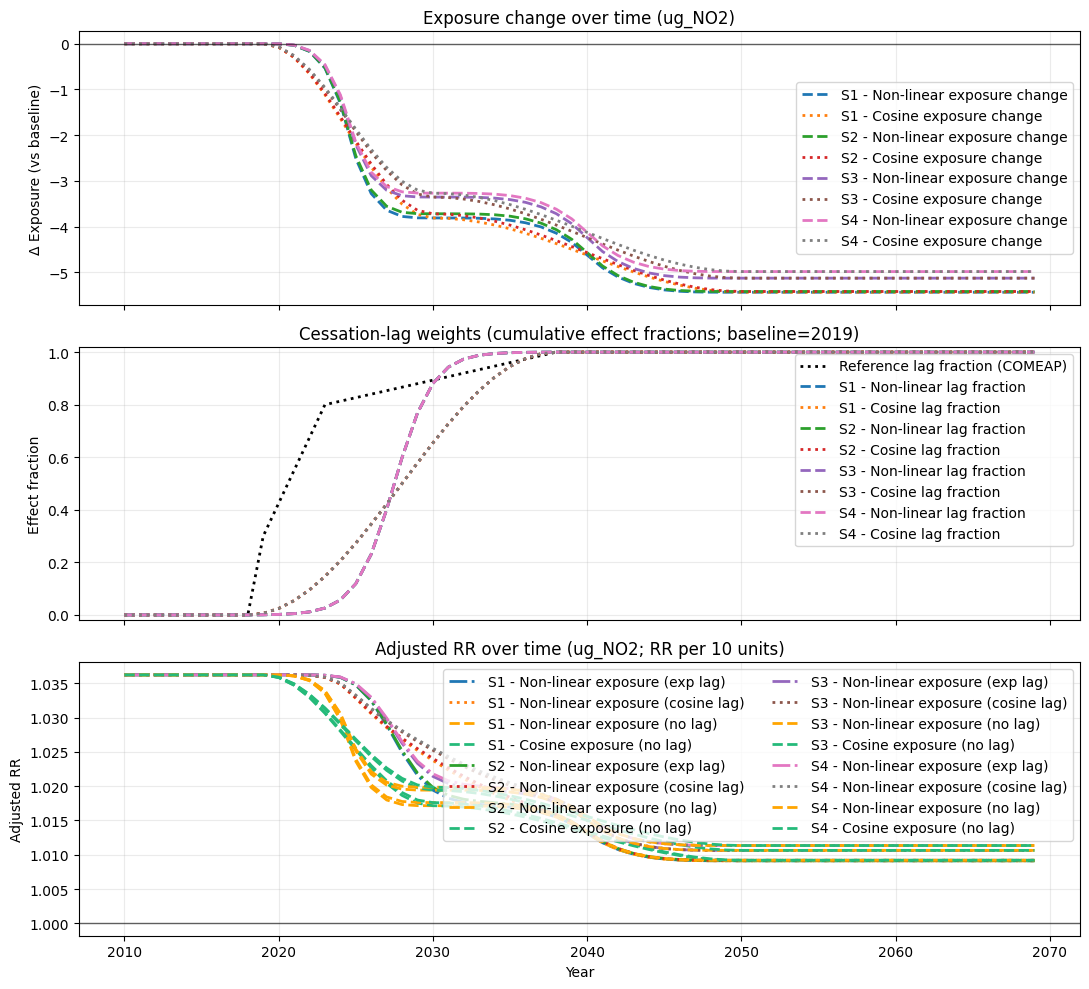

In [33]:
# Plot: (1) exposure change, (2) cessation-lag weights (effect fractions), (3) adjusted RR over time (including "no lag" effect)
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
ax0, ax1, ax2 = axes
scenario_list = scenarios if "scenarios" in globals() and len(scenarios) else rr_plot_df["scenario"].unique().tolist()
pollutant_to_plot = pollutants[0] if "pollutants" in globals() and len(pollutants) else rr_plot_df["pollutant"].iloc[0]
_ref_years = (
    rr_plot_df[rr_plot_df["pollutant"] == pollutant_to_plot]["year"].dropna().astype(int).unique()
)
_ref_years = np.sort(_ref_years)
_ref_delay_w = _calculate_delay_weights_30y(
    first_year_share=0.30, years_2_5_share=0.50, years_6_20_share=0.20
)
_ref_frac = _cumulative_effect_fraction(_ref_years, BASELINE_YEAR, _ref_delay_w)

ax1.plot(
    _ref_years,
    _ref_frac,
    color="black",
    linewidth=2,
    linestyle=":",
    label="Reference lag fraction (COMEAP)",
)

for scenario in scenario_list:
    sub = (
        rr_plot_df[(rr_plot_df["scenario"] == scenario) & (rr_plot_df["pollutant"] == pollutant_to_plot)]
        .sort_values("year")
        .copy()
    )
    if sub.empty:
        continue

    # (1) Exposure change (delta C) relative to baseline
    #ax0.plot(
        #sub["year"],
        #sub["delta_c_year_linear"],
        #linewidth=2,
        #label=f"{scenario.upper()} - Linear exposure change",
    #)
    ax0.plot(
        sub["year"],
        sub["delta_c_year_nonlinear"],
        linewidth=2,
        linestyle="--",
        label=f"{scenario.upper()} - Non-linear exposure change",
    )
    ax0.plot(
        sub["year"],
        sub["delta_c_year_cosine"],
        linewidth=2,
        linestyle=":",
        label=f"{scenario.upper()} - Cosine exposure change",
    )

    # (2) Weights / effect fractions (cumulative effect fractions)
    #ax1.plot(
        #sub["year"],
        #sub["frac_linear"],
        #linewidth=2,
        #linestyle="-",
        #label=f"{scenario.upper()} - Linear lag fraction",
    #)
    ax1.plot(
        sub["year"],
        sub["frac_nonlinear"],
        linewidth=2,
        linestyle="--",
        label=f"{scenario.upper()} - Non-linear lag fraction",
    )
    ax1.plot(
        sub["year"],
        sub["frac_cosine"],
        linewidth=2,
        linestyle=":",
        label=f"{scenario.upper()} - Cosine lag fraction",
    )

    # (3) Adjusted RR (linear vs non-linear exposure; linear lag vs exponential lag)
    #ax2.plot(
        #sub["year"],
        #sub["rr_adj_linear_linlag"],
        #linewidth=2,
        #linestyle="-",
        #label=f"{scenario.upper()} - Linear exposure (linear lag)",
    #)
    ax2.plot(
        sub["year"],
        sub["rr_adj_nonlinear_nonlinlag"],
        linewidth=2,
        linestyle="-.",
        label=f"{scenario.upper()} - Non-linear exposure (exp lag)",
    )
    ax2.plot(
        sub["year"],
        sub["rr_adj_nonlinear_cosine"],
        linewidth=2,
        linestyle=":",
        label=f"{scenario.upper()} - Non-linear exposure (cosine lag)",
    )
    # === : Add "no lag" (immediate effect) RR curves ===
    #ax2.plot(
        #sub["year"],
        #sub["rr_adj_linear_nolag"],
        #linewidth=2,
        #linestyle="--",
        #color="#6666ff",
        #label=f"{scenario.upper()} - Linear exposure (no lag)",
    #)
    ax2.plot(
        sub["year"],
        sub["rr_adj_nonlinear_nolag"],
        linewidth=2,
        linestyle="--",
        color="#ffa500",
        label=f"{scenario.upper()} - Non-linear exposure (no lag)",
    )
    ax2.plot(
        sub["year"],
        sub["rr_adj_cosine_nolag"],
        linewidth=2,
        linestyle="--",
        color="#25ba7a",
        label=f"{scenario.upper()} - Cosine exposure (no lag)",
    )

ax0.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax0.set_title(f"Exposure change over time ({pollutant_to_plot})")
ax0.set_ylabel("Δ Exposure (vs baseline)")
ax0.grid(True, alpha=0.25)
ax0.legend()

ax1.set_title(f"Cessation-lag weights (cumulative effect fractions; baseline={BASELINE_YEAR})")
ax1.set_ylabel("Effect fraction")
ax1.set_ylim(-0.02, 1.02)
ax1.grid(True, alpha=0.25)
ax1.legend()

ax2.axhline(1.0, color="black", linewidth=1, alpha=0.6)
ax2.set_title(f"Adjusted RR over time ({pollutant_to_plot}; RR per {UNIT_CHANGE:g} units)")
ax2.set_xlabel("Year")
ax2.set_ylabel("Adjusted RR")
ax2.grid(True, alpha=0.25)
ax2.legend(ncol=2)

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import numpy as np
# Assume rr_plot_df is already created as in your code (with all RR, lagged and no-lag columns)
yearly_results = []

for pollutant in rr_plot_df['pollutant'].unique():
    for scenario in rr_plot_df['scenario'].unique():
        sub = rr_plot_df[(rr_plot_df['pollutant'] == pollutant) & (rr_plot_df['scenario'] == scenario)].copy()

        for exposure_shape, lag_shape, rr_col in [
            ('linear', 'linear', 'rr_adj_linear_linlag'),
            ('linear', 'nonlin', 'rr_adj_linear_nonlinlag'),
            ('linear', 'cosine', 'rr_adj_linear_cosine'),
            ('nonlinear', 'linear', 'rr_adj_nonlinear_linlag'),
            ('nonlinear', 'nonlin', 'rr_adj_nonlinear_nonlinlag'),
            ('nonlinear', 'cosine', 'rr_adj_nonlinear_cosine'),
            ('cosine', 'linear', 'rr_adj_cosine_nolag'),  # adjust as needed for lag column
        ]:
            # Select the corresponding no-lag RR for each exposure shape
            if exposure_shape == 'linear':
                rr_no_lag = sub['rr_adj_linear_nolag'].values
            elif exposure_shape == 'nonlinear':
                rr_no_lag = sub['rr_adj_nonlinear_nolag'].values
            elif exposure_shape == 'cosine':
                rr_no_lag = sub['rr_adj_cosine_nolag'].values
            else:
                continue

            rr_lagged = sub[rr_col].values
            years = sub['year'].values

            excess_no_lag = rr_no_lag - 1.0
            excess_lagged = rr_lagged - 1.0
            # Annual multiplier: lagged / no-lag (per year)
            with np.errstate(divide='ignore', invalid='ignore'):
                multiplier_year = np.where(excess_no_lag != 0, excess_lagged / excess_no_lag, np.nan)

            for idx, yr in enumerate(years):
                yearly_results.append({
                    'pollutant': pollutant,
                    'scenario': scenario,
                    'exposure_shape': exposure_shape,
                    'lag_shape': lag_shape,
                    'year': int(yr),
                    'excess_no_lag': excess_no_lag[idx],
                    'excess_lagged': excess_lagged[idx],
                    'multiplier_lagged_over_nolag': multiplier_year[idx],
                })

year_df = pd.DataFrame(yearly_results)
out_path = "data/2-output-data/Cessation_lags/cessation_lag_multipliers_by_year_NO2.csv"
year_df.to_csv(out_path, index=False)
print(f"Saved {out_path}")

Saved data/2-output-data/Cessation_lags/cessation_lag_multipliers_by_year_NO2.csv


In [34]:
import re
from scipy.interpolate import PchipInterpolator, CubicSpline
# ---------------- HELPERS ----------------
def _norm_text(x: str) -> str:
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = re.sub(r"\([^)]*\)", "", s)
    s = re.sub(r"[^0-9a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def lin_interp(v0, v1, y0, y1, y):
    if y1 == y0:
        return v0
    return v0 + (v1 - v0) * (y - y0) / (y1 - y0)


def interp_cubic_spline(v2019, v2030, v2050, year):
    """Smooth cubic spline interpolation - C2 continuous"""
    years = np.array([2019, 2030, 2050])
    values = np.array([v2019, v2030, v2050])
    cs = CubicSpline(years, values)
    return float(cs(year))


def interp_pchip_smooth(v2019, v2030, v2050, year):
    """
    PCHIP interpolation: smooth, shape-preserving, no overshoot.
    Better than linear for health/economic projections.
    """
    years = np.array([2019, 2030, 2050])
    values = np.array([v2019, v2030, v2050])

    if np.allclose(values, values[0]):
        return float(values[0])

    interpolator = PchipInterpolator(years, values)
    result = float(interpolator(year))
    return max(0.0, result)


def interp_piecewise(v2019, v2030, v2050, year):
    return interp_pchip_smooth(v2019, v2030, v2050, year)


def find_col(df, *candidates):
    for cand in candidates:
        for c in df.columns:
            if cand.lower() in c.lower():
                return c
    return None


def safe_sum(df, col):
    if col is None or col not in df.columns:
        return 0.0
    return pd.to_numeric(df[col], errors="coerce").fillna(0).sum()

In [35]:
import os
import pandas as pd
import numpy as np
from morbidity_chimere_module import *

CESSATION_LAGS_DIR = r"data\2-output-data\Cessation_lags"
# CONFIG
scenarios = ["s1", "s2", "s3", "s4"]
pollutant_labels = {
    "ug_PM25_RH50": "PM2.5",
    "ug_NO2": "NO2",
}
ANCHOR_YEARS = [2019, 2030, 2050]
FULL_YEARS = list(range(2019, 2051))

DISEASE_TO_HEALTH_OUTCOME = {
    "Hypertension": "Hypertension (18+)",
    "Lung Cancer": "Lung Cancer (35+)",
    "Asthma in children": "Asthma (0–17)",
    "Asthma in adult": "Asthma (18–39)",
    "COPD": "COPD (40+)",
    "ALRI in children": "ALRI (0–12) per episode",
    "Stroke": "Stroke (35+)",
    "IHD events": "Myocardial Infarction (30+)",
    "Diabetes T2": "Type 2 Diabetes (45+)",
}
CESS_LAG_BASE = r"data/2-output-data/Cessation_lags"
MULTIPLIER_FILES = {
    "ug_PM25_RH50": os.path.join(CESS_LAG_BASE, "cessation_lag_multipliers_by_year_PM2.5.csv"),
    "ug_NO2": os.path.join(CESS_LAG_BASE, "cessation_lag_multipliers_by_year_NO2.csv"),
}

summary_data = []
for sc in scenarios:
    for pol in pollutant_labels:
        # ---- Load corresponding multiplier CSV for the current pollutant ----
        MULTIPLIER_FILE = MULTIPLIER_FILES[pol]
        if not os.path.exists(MULTIPLIER_FILE):
            raise FileNotFoundError(f"Multiplier file {MULTIPLIER_FILE} not found")
        multiplier_df = pd.read_csv(MULTIPLIER_FILE)
        multiplier_df['pollutant'] = multiplier_df['pollutant'].str.strip().str.upper()

        # Helper function for this pollutant
        def get_lag_multiplier(pollutant, year, lag_shape, exposure_shape="linear"):
            poln = str(pollutant).strip().upper()
            yr = int(year)
            df = multiplier_df[
                (multiplier_df['pollutant'] == poln) &
                (multiplier_df['year'] == yr) &
                (multiplier_df['lag_shape'] == lag_shape) &
                (multiplier_df['exposure_shape'] == exposure_shape)
            ]
            if df.empty or "multiplier_lagged_over_nolag" not in df.columns:
                return 1.0
            val = df.iloc[0]["multiplier_lagged_over_nolag"]
            return float(val) if np.isfinite(val) else 1.0

        anchors = {}

        # ---------- ZERO BASELINE (2019) ----------
        anchors[2019] = {
            "morb": {
                cfg["disease"]: {
                    "cases_c": 0.0, "cases_l": 0.0, "cases_u": 0.0,
                    "yld_c": 0.0, "yld_l": 0.0, "yld_u": 0.0,
                }
                for cfg in morb_config
            },
            "mort": {
                "deaths_c": 0.0, "deaths_l": 0.0, "deaths_u": 0.0,
                "yll_c": 0.0, "yll_l": 0.0, "yll_u": 0.0,
            },
        }

        # ---------- LOAD 2030 & 2050 ----------
        for yr in [2030, 2050]:
            base_path = os.path.join("data", "2-output-data", sc, pol, str(yr))
            morb_file = os.path.join(base_path, "morbidity_results.csv")
            mort_file = os.path.join(base_path, "mortality_chimere.csv")

            if not os.path.exists(morb_file):
                continue

            morb_df = pd.read_csv(morb_file)
            morb_anchor = {}
            for cfg in morb_config:
                d = cfg["disease"]
                df_d = morb_df[morb_df["disease"] == d]
                if df_d.empty:
                    continue
                morb_anchor[d] = {
                    "cases_c": df_d["avoided_cases_central"].sum(),
                    "cases_l": df_d["avoided_cases_low"].sum(),
                    "cases_u": df_d["avoided_cases_high"].sum(),
                    "yld_c": df_d["YLD_central"].sum(),
                    "yld_l": df_d["YLD_low"].sum(),
                    "yld_u": df_d["YLD_high"].sum(),
                }

            mort_anchor = {
                "deaths_c": 0.0, "deaths_l": 0.0, "deaths_u": 0.0,
                "yll_c": 0.0, "yll_l": 0.0, "yll_u": 0.0,
            }
            if os.path.exists(mort_file):
                mort_df = pd.read_csv(mort_file)
                mort_anchor["deaths_c"] = safe_sum(mort_df, find_col(mort_df, "mortpol_age"))
                mort_anchor["deaths_l"] = safe_sum(mort_df, find_col(mort_df, "mortpol_LCI"))
                mort_anchor["deaths_u"] = safe_sum(mort_df, find_col(mort_df, "mortpol_UCI"))
                mort_anchor["yll_c"] = safe_sum(mort_df, find_col(mort_df, "YLG"))
                mort_anchor["yll_l"] = safe_sum(mort_df, find_col(mort_df, "YLG_LCI"))
                mort_anchor["yll_u"] = safe_sum(mort_df, find_col(mort_df, "YLG_UCI"))
            anchors[yr] = {"morb": morb_anchor, "mort": mort_anchor}
        if not {2019, 2030, 2050}.issubset(anchors):
            continue

        # ---------- Load baseline deaths (2030 reference) ----------
        baseline_deaths = 1.0
        baseline_yll = 1.0
        mort_file_2030 = os.path.join("data", "2-output-data", sc, pol, "2030", "mortality_chimere_mc.csv")
        if os.path.exists(mort_file_2030):
            mort_df_2030 = pd.read_csv(mort_file_2030)
            baseline_deaths = safe_sum(mort_df_2030, find_col(mort_df_2030, "baseline"))
            baseline_yll = safe_sum(mort_df_2030, find_col(mort_df_2030, "yll_baseline", "ylg_baseline"))
            if baseline_deaths <= 0:
                baseline_deaths = 1.0
            if baseline_yll <= 0:
                baseline_yll = 1.0

        for year in FULL_YEARS:
            for lag_shape in ["no_lag", "cosine", "nonlin"]:
                exposure_shape = "linear"  # or refine as needed

                if lag_shape == "no_lag":
                    mortality_lag = 1.0
                else:
                    mortality_lag = get_lag_multiplier(pol, year, lag_shape, exposure_shape)

                combo_cases_c = 0.0
                combo_cases_l = 0.0
                combo_cases_u = 0.0
                combo_yld_c = 0.0
                combo_yld_l = 0.0
                combo_yld_u = 0.0

                for cfg in morb_config:
                    d = cfg["disease"]
                    outcome = DISEASE_TO_HEALTH_OUTCOME.get(d, d)
                    m19 = anchors[2019]["morb"][d]
                    m30 = anchors[2030]["morb"].get(d, m19)
                    m50 = anchors[2050]["morb"].get(d, m19)
                    cases_c = interp_piecewise(m19["cases_c"], m30["cases_c"], m50["cases_c"], year)
                    cases_l = interp_piecewise(m19["cases_l"], m30["cases_l"], m50["cases_l"], year)
                    cases_u = interp_piecewise(m19["cases_u"], m30["cases_u"], m50["cases_u"], year)
                    yld_c = interp_piecewise(m19["yld_c"], m30["yld_c"], m50["yld_c"], year)
                    yld_l = interp_piecewise(m19["yld_l"], m30["yld_l"], m50["yld_l"], year)
                    yld_u = interp_piecewise(m19["yld_u"], m30["yld_u"], m50["yld_u"], year)
                    morb_lag = (1.0 if lag_shape == "no_lag"
                        else get_lag_multiplier(pol, year, lag_shape, exposure_shape))
                    combo_cases_c += cases_c * morb_lag
                    combo_cases_l += cases_l * morb_lag
                    combo_cases_u += cases_u * morb_lag
                    combo_yld_c += yld_c * morb_lag
                    combo_yld_l += yld_l * morb_lag
                    combo_yld_u += yld_u * morb_lag

                # --- Mortality (AF method) with multiplier ---
                m19 = anchors[2019]["mort"]
                m30 = anchors[2030]["mort"]
                m50 = anchors[2050]["mort"]
                af19 = m19["deaths_c"] / baseline_deaths
                af30 = m30["deaths_c"] / baseline_deaths
                af50 = m50["deaths_c"] / baseline_deaths
                af_interp = interp_piecewise(af19, af30, af50, year)
                deaths_c = baseline_deaths * af_interp * mortality_lag
                af_yll19 = m19["yll_c"] / baseline_yll
                af_yll30 = m30["yll_c"] / baseline_yll
                af_yll50 = m50["yll_c"] / baseline_yll
                af_yll_interp = interp_piecewise(af_yll19, af_yll30, af_yll50, year)
                yll_c = baseline_yll * af_yll_interp * mortality_lag
                # --- Store all results with lag type info
                summary_data.append(
                    {
                        "Scenario": sc,
                        "Pollutant": pollutant_labels[pol],
                        "Year": year,
                        "Lag Structure": lag_shape,
                        "Deaths Avoided": round(deaths_c, 0),
                        "YLL Avoided": round(yll_c, 0),
                        "Avoided Cases": round(combo_cases_c, 0),
                        "YLD Avoided": round(combo_yld_c, 0),
                    }
                )

# Convert to DataFrame and save
summary_df = pd.DataFrame(summary_data)
out = "data/2-output-data/economic_summary_interpolated_2019_2050_multilag.csv"
summary_df.to_csv(out, index=False)
print(f"Saved: {out}")

Saved: data/2-output-data/economic_summary_interpolated_2019_2050_multilag.csv


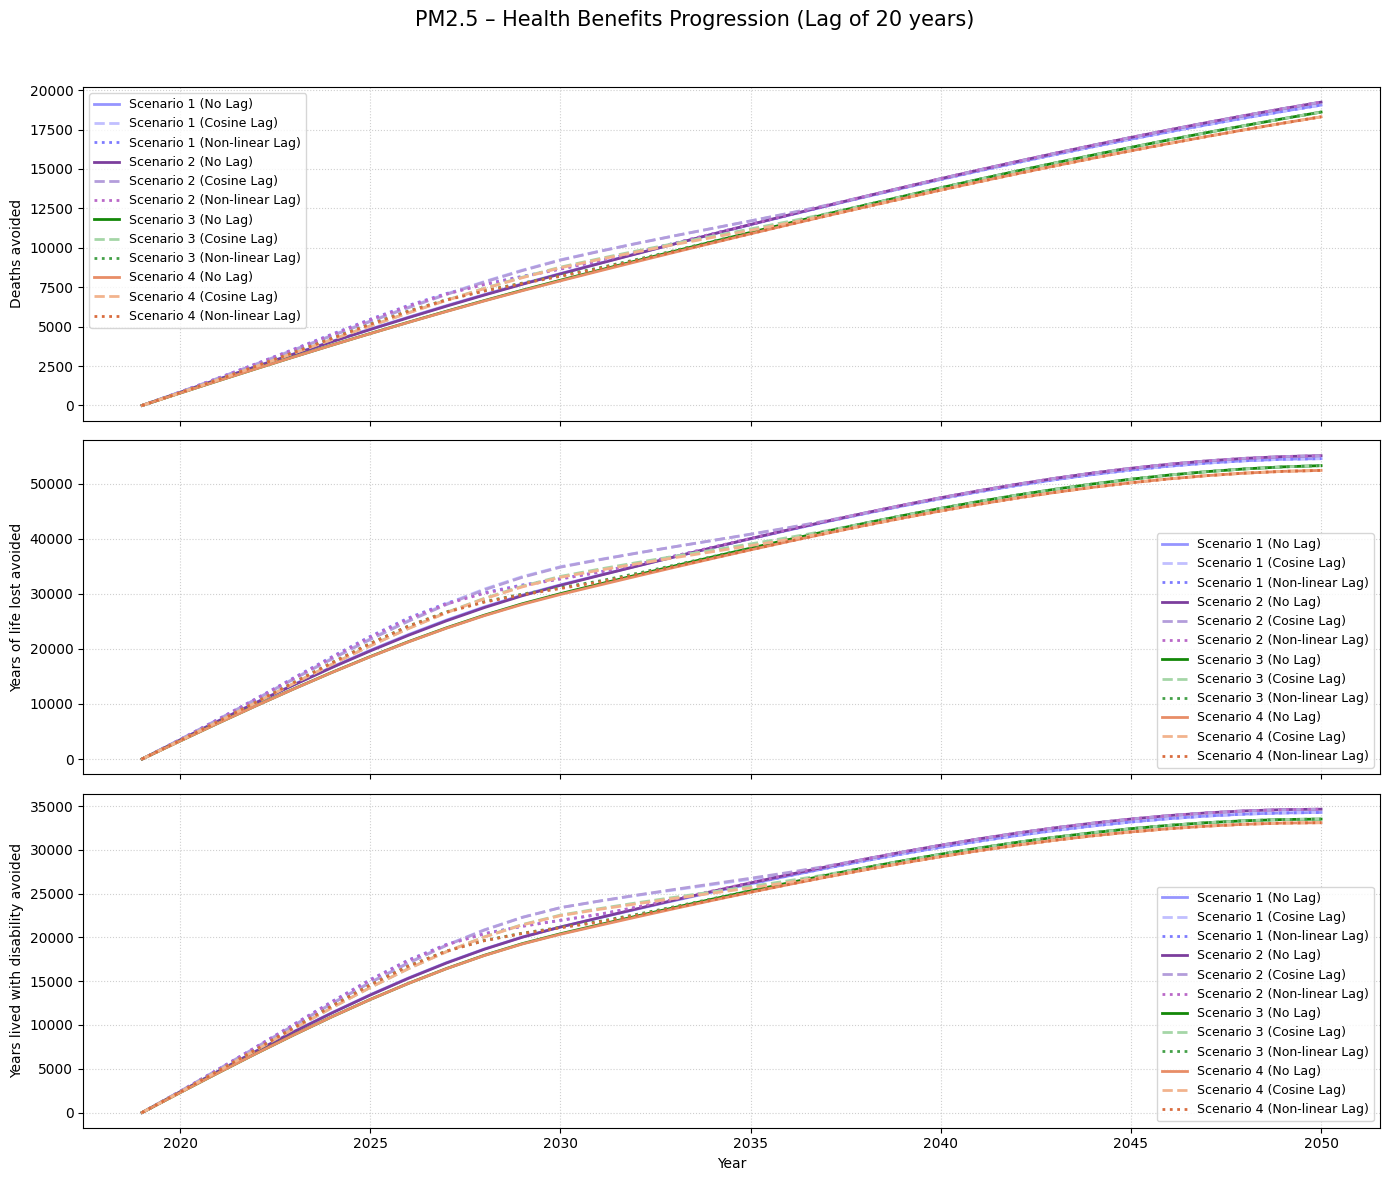

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------- LOAD ----------------
df = pd.read_csv("data/2-output-data/economic_summary_interpolated_2019_2050_multilag.csv")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)

# ---------------- FILTER ----------------
pollutant = "PM2.5"  # Change to "NO2" as needed
df_plot = df[df["Pollutant"] == pollutant].copy()

# Ensure numeric
for col in ["Deaths Avoided", "YLL Avoided", "YLD Avoided"]:
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce").fillna(0)

# ---------------- PLOTTING ----------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
metrics = [
    ("Deaths Avoided", "Deaths avoided"),
    ("YLL Avoided", "Years of life lost avoided"),
    ("YLD Avoided", "Years lived with disability avoided"),
]

scenarios = ["s1", "s2", "s3", "s4"]
scenario_labels = {"s1": "Scenario 1", "s2": "Scenario 2", "s3": "Scenario 3", "s4": "Scenario 4"}
scenario_colors = {"s1": "#9695FF", "s2": "#B47CC7", "s3": "#6ABF69", "s4": "#E88D67"}
lag_structures = ["no_lag", "cosine", "nonlin"]
lag_labels = {
    "no_lag": "No Lag",
    "cosine": "Cosine Lag",
    "nonlin": "Non-linear Lag"
}
color_map = {
    ("s1", "no_lag"): "#9695FF",
    ("s1", "cosine"): "#C1BFFF",
    ("s1", "nonlin"): "#7D7BFF",
    ("s2", "no_lag"): "#7C3E9D",  # Strong purple (S2 no lag)
    ("s2", "cosine"): "#B39DDB",  # Lavender (S2 cosine lag, light purple)
    ("s2", "nonlin"): "#BA68C8",  # Medium orchid (S2 non-linear lag, medium purple)
    ("s3", "no_lag"): "#138808",  # Strong green (S3 no lag)
    ("s3", "cosine"): "#A5D6A7",  # Mint green (S3 cosine lag, light green)
    ("s3", "nonlin"): "#43A047",  # Medium green (S3 non-linear lag, medium/dark green)
    ("s4", "no_lag"): "#E88D67",
    ("s4", "cosine"): "#F2B38D",
    ("s4", "nonlin"): "#D96C3E",
}

line_map = {
    "no_lag": "-",  # solid
    "cosine": "--",  # dashed
    "nonlin": ":"  # dotted
}

for ax, (metric, ylabel) in zip(axes, metrics):
    for sc in scenarios:
        for lag in lag_structures:
            this_df = df_plot[(df_plot["Scenario"] == sc) & (df_plot["Lag Structure"] == lag)].sort_values("Year")
            if this_df.empty:
                continue
            col = color_map.get((sc, lag), scenario_colors.get(sc.upper(), None))
            style = line_map.get(lag, "-")
            ax.plot(
                this_df["Year"],
                this_df[metric],
                color=col,
                linestyle=style,
                linewidth=2,
                label=f"{scenario_labels[sc]} ({lag_labels[lag]})",
            )
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle=":", alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=9)

axes[-1].set_xlabel("Year")
fig.suptitle(
    f"{pollutant} – Health Benefits Progression (Lag of 20 years)",
    fontsize=15,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
